# Financial Market Movement Prediction Using News Sentiment and Market Data

## Notebook 2: Sentiment Analysis and Feature Engineering

**Selected Stock:** Apple Inc. (AAPL)

**Objective:** Build and evaluate a financial-news sentiment classification pipeline, generate sentiment features, and combine them with Apple’s market indicators.

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Locate the project folders
project_root = (
    Path.cwd().parent
    if Path.cwd().name.lower() == "notebooks"
    else Path.cwd()
)

processed_data_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
figures_dir = project_root / "outputs" / "figures"

models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Load the cleaned financial-news dataset
clean_news_file = processed_data_dir / "financial_news_clean.csv"
news_clean = pd.read_csv(clean_news_file)

print("Libraries imported successfully!")
print("Cleaned news shape:", news_clean.shape)

display(news_clean.head())

Libraries imported successfully!
Cleaned news shape: (4835, 4)


,Sentiment,Headline,Clean_Headline,Sentiment_Score
0,neutral,"According to Gran , the company has no plans t...",according to gran the company has no plans to ...,0
1,neutral,Technopolis plans to develop in stages an area...,technopolis plans to develop in stages an area...,0
2,negative,The international electronic industry company ...,the international electronic industry company ...,-1
3,positive,With the new production plant the company woul...,with the new production plant the company woul...,1
4,positive,According to the company 's updated strategy f...,according to the company s updated strategy fo...,1


In [2]:
# Define input text and sentiment labels
X = news_clean["Clean_Headline"]
y = news_clean["Sentiment"]

# First split: 70% training and 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide temporary data equally
# Final split = 70% training, 15% validation, 15% testing
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_validation))
print("Testing samples:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

Training samples: 3384
Validation samples: 725
Testing samples: 726

Training sentiment distribution:
Sentiment
neutral     2008
positive     953
negative     423
Name: count, dtype: int64


In [3]:
# Build the NLP sentiment-analysis pipeline
sentiment_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=12000,
            ngram_range=(1, 2),
            min_df=2,
            strip_accents="unicode",
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

# Train using the training set only
sentiment_pipeline.fit(X_train, y_train)

# Evaluate using the validation set
validation_predictions = sentiment_pipeline.predict(X_validation)

validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions
)

validation_macro_f1 = f1_score(
    y_validation,
    validation_predictions,
    average="macro"
)

print("Sentiment pipeline trained successfully!")
print(f"Validation accuracy: {validation_accuracy:.4f}")
print(f"Validation macro F1-score: {validation_macro_f1:.4f}")

print("\nValidation classification report:")
print(
    classification_report(
        y_validation,
        validation_predictions,
        digits=4
    )
)

Sentiment pipeline trained successfully!
Validation accuracy: 0.7545
Validation macro F1-score: 0.7022

Validation classification report:
              precision    recall  f1-score   support

    negative     0.6279    0.5934    0.6102        91
     neutral     0.8180    0.8256    0.8218       430
    positive     0.6732    0.6765    0.6748       204

    accuracy                         0.7545       725
   macro avg     0.7064    0.6985    0.7022       725
weighted avg     0.7534    0.7545    0.7539       725



In [4]:
# Combine training and validation data for final training
X_final_train = pd.concat(
    [X_train, X_validation],
    ignore_index=True
)

y_final_train = pd.concat(
    [y_train, y_validation],
    ignore_index=True
)

# Retrain the selected pipeline
sentiment_pipeline.fit(X_final_train, y_final_train)

# Evaluate once on the untouched test set
test_predictions = sentiment_pipeline.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro"
)

print(f"Final test accuracy: {test_accuracy:.4f}")
print(f"Final test macro F1-score: {test_macro_f1:.4f}")

print("\nFinal test classification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        digits=4
    )
)

# Save the complete TF-IDF and Logistic Regression pipeline
sentiment_model_file = (
    models_dir / "financial_sentiment_pipeline.joblib"
)

joblib.dump(
    sentiment_pipeline,
    sentiment_model_file
)

print("\nSentiment pipeline saved to:")
print(sentiment_model_file)

Final test accuracy: 0.8003
Final test macro F1-score: 0.7687

Final test classification report:
              precision    recall  f1-score   support

    negative     0.7172    0.7889    0.7513        90
     neutral     0.8497    0.8654    0.8575       431
    positive     0.7287    0.6683    0.6972       205

    accuracy                         0.8003       726
   macro avg     0.7652    0.7742    0.7687       726
weighted avg     0.7991    0.8003    0.7991       726


Sentiment pipeline saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\models\financial_sentiment_pipeline.joblib


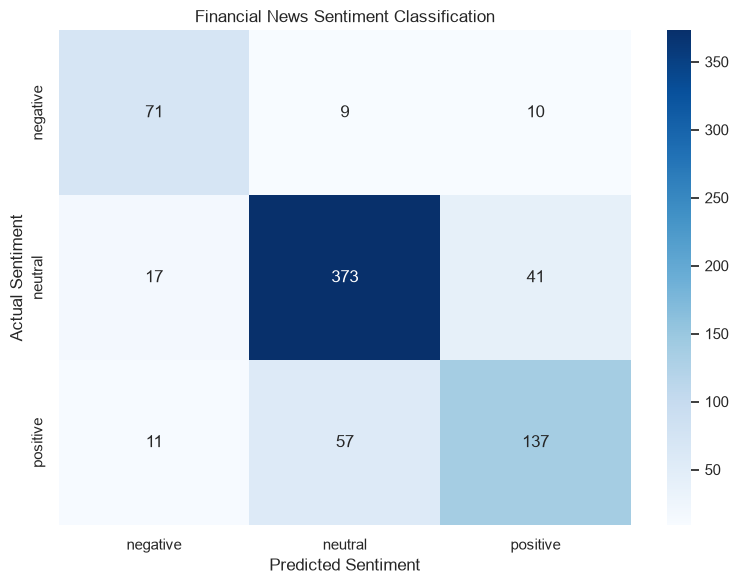

Confusion matrix saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\outputs\figures\sentiment_confusion_matrix.png


In [5]:
# Define a consistent class order
sentiment_labels = ["negative", "neutral", "positive"]

# Calculate the confusion matrix
sentiment_cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=sentiment_labels
)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    sentiment_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sentiment_labels,
    yticklabels=sentiment_labels
)

plt.title("Financial News Sentiment Classification")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()

# Save the graph
sentiment_cm_file = (
    figures_dir / "sentiment_confusion_matrix.png"
)

plt.savefig(
    sentiment_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(sentiment_cm_file)

In [6]:
# Locate the historical Apple-news dataset
raw_data_dir = project_root / "data" / "raw"
apple_news_file = raw_data_dir / "apple_news_data.csv"

# Load the dataset
try:
    apple_news = pd.read_csv(
        apple_news_file,
        encoding="utf-8",
        low_memory=False
    )
except UnicodeDecodeError:
    apple_news = pd.read_csv(
        apple_news_file,
        encoding="latin-1",
        low_memory=False
    )

print("Apple news shape:", apple_news.shape)

print("\nColumn names:")
print(apple_news.columns.tolist())

print("\nMissing values:")
print(apple_news.isnull().sum())

print("\nDuplicate rows:", apple_news.duplicated().sum())

display(apple_news.head())

Apple news shape: (29752, 10)

Column names:
['date', 'title', 'content', 'link', 'symbols', 'tags', 'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos']

Missing values:
date                      0
title                     0
content                   0
link                      0
symbols                   0
tags                  12188
sentiment_polarity       15
sentiment_neg            15
sentiment_neu            15
sentiment_pos            15
dtype: int64

Duplicate rows: 0


,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [7]:
import re

# Keep the required news fields
apple_news_scored = apple_news[
    ["date", "title", "content", "link", "symbols"]
].copy()

# Keep records connected to Apple/AAPL
apple_news_scored = apple_news_scored[
    apple_news_scored["symbols"]
    .astype(str)
    .str.contains("AAPL", case=False, na=False)
].copy()

# Convert the publication date into a standard daily date
apple_news_scored["News_Date"] = pd.to_datetime(
    apple_news_scored["date"]
    .astype(str)
    .str[:10],
    errors="coerce"
)

# Remove records without valid dates or titles
apple_news_scored.dropna(
    subset=["News_Date", "title"],
    inplace=True
)

# Clean text using the same rules used for model training
def prepare_apple_headline(text):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s%$.-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

apple_news_scored["Clean_Title"] = (
    apple_news_scored["title"]
    .apply(prepare_apple_headline)
)

# Remove empty and repeated headlines from the same day
apple_news_scored = apple_news_scored[
    apple_news_scored["Clean_Title"].str.len() > 0
]

apple_news_scored.drop_duplicates(
    subset=["News_Date", "Clean_Title"],
    keep="first",
    inplace=True
)

apple_news_scored.reset_index(drop=True, inplace=True)

# Predict sentiment labels
apple_news_scored["Predicted_Sentiment"] = (
    sentiment_pipeline.predict(
        apple_news_scored["Clean_Title"]
    )
)

# Generate sentiment probabilities
sentiment_probabilities = sentiment_pipeline.predict_proba(
    apple_news_scored["Clean_Title"]
)

sentiment_classes = (
    sentiment_pipeline
    .named_steps["classifier"]
    .classes_
)

probability_data = pd.DataFrame(
    sentiment_probabilities,
    columns=sentiment_classes,
    index=apple_news_scored.index
)

apple_news_scored["Negative_Score"] = (
    probability_data["negative"]
)
apple_news_scored["Neutral_Score"] = (
    probability_data["neutral"]
)
apple_news_scored["Positive_Score"] = (
    probability_data["positive"]
)

# Overall score ranges from -1 to +1
apple_news_scored["Sentiment_Score"] = (
    apple_news_scored["Positive_Score"]
    - apple_news_scored["Negative_Score"]
)

# Save the scored headlines
scored_news_file = (
    processed_data_dir / "AAPL_news_scored.csv"
)

apple_news_scored.to_csv(
    scored_news_file,
    index=False
)

print("Scored Apple-news shape:", apple_news_scored.shape)
print(
    "Date range:",
    apple_news_scored["News_Date"].min().date(),
    "to",
    apple_news_scored["News_Date"].max().date()
)

print("\nPredicted sentiment distribution:")
print(
    apple_news_scored[
        "Predicted_Sentiment"
    ].value_counts()
)

print("\nSaved to:", scored_news_file)

display(
    apple_news_scored[
        [
            "News_Date",
            "title",
            "Predicted_Sentiment",
            "Negative_Score",
            "Neutral_Score",
            "Positive_Score",
            "Sentiment_Score"
        ]
    ].head()
)

Scored Apple-news shape: (28708, 12)
Date range: 2016-02-19 to 2024-11-27

Predicted sentiment distribution:
Predicted_Sentiment
neutral     20824
positive     6201
negative     1683
Name: count, dtype: int64

Saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\data\processed\AAPL_news_scored.csv


,News_Date,title,Predicted_Sentiment,Negative_Score,Neutral_Score,Positive_Score,Sentiment_Score
0,2024-11-27,Berkshire Stock Hits Record Even as Company Re...,positive,0.136257,0.399480,0.464263,0.328007
1,2024-11-26,What Is a Stock Market Index?,neutral,0.109100,0.721886,0.169014,0.059915
2,2024-11-26,"Could Investing $1,000 in Apple Make You a Mil...",neutral,0.216051,0.583918,0.200031,-0.016019
3,2024-11-26,Dow Jones Industrial Average,neutral,0.158741,0.602331,0.238928,0.080187
4,2024-11-26,What Is the S&P 500 Index?,neutral,0.099097,0.780983,0.119920,0.020823


In [8]:
# Load Apple's feature-engineered market data
market_features_file = (
    processed_data_dir / "AAPL_market_features.csv"
)

market_features = pd.read_csv(
    market_features_file
)

market_features["Date"] = pd.to_datetime(
    market_features["Date"]
)

# Create an ordered list of valid Apple trading dates
trading_dates = np.sort(
    market_features["Date"].dropna().unique()
)

# Map weekend and market-holiday news to the next trading day
news_dates = apple_news_scored[
    "News_Date"
].to_numpy(dtype="datetime64[ns]")

trading_positions = np.searchsorted(
    trading_dates,
    news_dates,
    side="left"
)

# Keep only news that can be mapped to a market date
valid_positions = (
    trading_positions < len(trading_dates)
)

apple_news_scored = apple_news_scored.loc[
    valid_positions
].copy()

trading_positions = trading_positions[
    valid_positions
]

apple_news_scored["Trading_Date"] = (
    trading_dates[trading_positions]
)

# Create count indicators
apple_news_scored["Positive_News"] = (
    apple_news_scored["Predicted_Sentiment"] == "positive"
).astype(int)

apple_news_scored["Neutral_News"] = (
    apple_news_scored["Predicted_Sentiment"] == "neutral"
).astype(int)

apple_news_scored["Negative_News"] = (
    apple_news_scored["Predicted_Sentiment"] == "negative"
).astype(int)

# Aggregate all sentiment features by trading day
daily_sentiment = (
    apple_news_scored
    .groupby("Trading_Date")
    .agg(
        Daily_Avg_Sentiment=(
            "Sentiment_Score",
            "mean"
        ),
        Daily_Positive_Score=(
            "Positive_Score",
            "mean"
        ),
        Daily_Neutral_Score=(
            "Neutral_Score",
            "mean"
        ),
        Daily_Negative_Score=(
            "Negative_Score",
            "mean"
        ),
        Positive_News_Count=(
            "Positive_News",
            "sum"
        ),
        Neutral_News_Count=(
            "Neutral_News",
            "sum"
        ),
        Negative_News_Count=(
            "Negative_News",
            "sum"
        ),
        Sentiment_Volatility=(
            "Sentiment_Score",
            "std"
        ),
        News_Count=(
            "Clean_Title",
            "count"
        )
    )
    .reset_index()
)

# A single article has no standard deviation
daily_sentiment["Sentiment_Volatility"] = (
    daily_sentiment["Sentiment_Volatility"]
    .fillna(0)
)

# Save the daily sentiment dataset
daily_sentiment_file = (
    processed_data_dir / "AAPL_daily_sentiment.csv"
)

daily_sentiment.to_csv(
    daily_sentiment_file,
    index=False
)

print("Daily sentiment shape:", daily_sentiment.shape)

print(
    "Trading-date range:",
    daily_sentiment["Trading_Date"].min().date(),
    "to",
    daily_sentiment["Trading_Date"].max().date()
)

print(
    "Total aggregated headlines:",
    daily_sentiment["News_Count"].sum()
)

print("\nSaved to:", daily_sentiment_file)

display(daily_sentiment.head())

Daily sentiment shape: (1140, 10)
Trading-date range: 2016-02-19 to 2024-11-27
Total aggregated headlines: 28708

Saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\data\processed\AAPL_daily_sentiment.csv


,Trading_Date,Daily_Avg_Sentiment,Daily_Positive_Score,Daily_Neutral_Score,Daily_Negative_Score,Positive_News_Count,Neutral_News_Count,Negative_News_Count,Sentiment_Volatility,News_Count
0,2016-02-19,0.077753,0.249595,0.578563,0.171842,0,1,0,0.0,1
1,2017-10-05,0.133402,0.254636,0.624130,0.121234,0,1,0,0.0,1
2,2017-11-27,0.179319,0.266446,0.646427,0.087127,0,1,0,0.0,1
3,2017-11-30,0.364564,0.446092,0.472380,0.081528,0,1,0,0.0,1
4,2018-01-31,0.111826,0.228450,0.654927,0.116624,0,1,0,0.0,1


In [9]:
# Add the remaining required technical indicators
market_features["BB_Middle"] = (
    market_features["Close"].rolling(window=20).mean()
)

bb_standard_deviation = (
    market_features["Close"].rolling(window=20).std()
)

market_features["BB_Upper"] = (
    market_features["BB_Middle"]
    + (2 * bb_standard_deviation)
)

market_features["BB_Lower"] = (
    market_features["BB_Middle"]
    - (2 * bb_standard_deviation)
)

market_features["BB_Width"] = (
    (
        market_features["BB_Upper"]
        - market_features["BB_Lower"]
    )
    / market_features["BB_Middle"]
)

# Add temporal features
market_features["Day_of_Week"] = (
    market_features["Date"].dt.dayofweek
)

market_features["Month"] = (
    market_features["Date"].dt.month
)

# Merge market and daily sentiment data
modeling_data = market_features.merge(
    daily_sentiment,
    how="left",
    left_on="Date",
    right_on="Trading_Date"
)

# Keep the period covered by the historical news dataset
news_start_date = daily_sentiment[
    "Trading_Date"
].min()

news_end_date = daily_sentiment[
    "Trading_Date"
].max()

modeling_data = modeling_data[
    (modeling_data["Date"] >= news_start_date)
    & (modeling_data["Date"] <= news_end_date)
].copy()

# Identify whether news was available on each day
modeling_data["News_Available"] = (
    modeling_data["News_Count"].notna()
).astype(int)

# Fill no-news days with zero
sentiment_feature_columns = [
    "Daily_Avg_Sentiment",
    "Daily_Positive_Score",
    "Daily_Neutral_Score",
    "Daily_Negative_Score",
    "Positive_News_Count",
    "Neutral_News_Count",
    "Negative_News_Count",
    "Sentiment_Volatility",
    "News_Count"
]

modeling_data[sentiment_feature_columns] = (
    modeling_data[sentiment_feature_columns]
    .fillna(0)
)

# Remove the duplicate merge-date column
modeling_data.drop(
    columns=["Trading_Date"],
    inplace=True
)

# Remove any initial rows unavailable for Bollinger Bands
modeling_data.dropna(inplace=True)
modeling_data.reset_index(drop=True, inplace=True)

# Save the unified modeling dataset
modeling_dataset_file = (
    processed_data_dir / "AAPL_modeling_dataset.csv"
)

modeling_data.to_csv(
    modeling_dataset_file,
    index=False
)

print("Unified dataset shape:", modeling_data.shape)
print(
    "Date range:",
    modeling_data["Date"].min().date(),
    "to",
    modeling_data["Date"].max().date()
)
print(
    "Remaining missing values:",
    modeling_data.isnull().sum().sum()
)
print(
    "Trading days with news:",
    modeling_data["News_Available"].sum()
)
print(
    "Trading days without news:",
    (modeling_data["News_Available"] == 0).sum()
)
print("\nSaved to:", modeling_dataset_file)

display(modeling_data.head())

Unified dataset shape: (2210, 41)
Date range: 2016-02-19 to 2024-11-27
Remaining missing values: 0
Trading days with news: 1140
Trading days without news: 1070

Saved to: c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\data\processed\AAPL_modeling_dataset.csv


,Date,Open,High,Low,Close,Adj Close,Volume,Next_Close,Target,Daily_Return,...,Daily_Avg_Sentiment,Daily_Positive_Score,Daily_Neutral_Score,Daily_Negative_Score,Positive_News_Count,Neutral_News_Count,Negative_News_Count,Sentiment_Volatility,News_Count,News_Available
0,2016-02-19,24.000000,24.190001,23.950001,24.010000,21.712439,141496800,24.219999,1,-0.002285,...,0.077753,0.249595,0.578563,0.171842,0.0,1.0,0.0,0.0,1.0,1
1,2016-02-22,24.077499,24.225000,23.980000,24.219999,21.902338,137123200,23.672501,0,0.008746,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
2,2016-02-23,24.100000,24.125000,23.637501,23.672501,21.407232,127770400,24.025000,1,-0.022605,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
3,2016-02-24,23.495001,24.094999,23.330000,24.025000,21.726004,145022800,24.190001,1,0.014891,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
4,2016-02-25,24.012501,24.190001,23.812500,24.190001,21.875214,110330800,24.227501,1,0.006868,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0


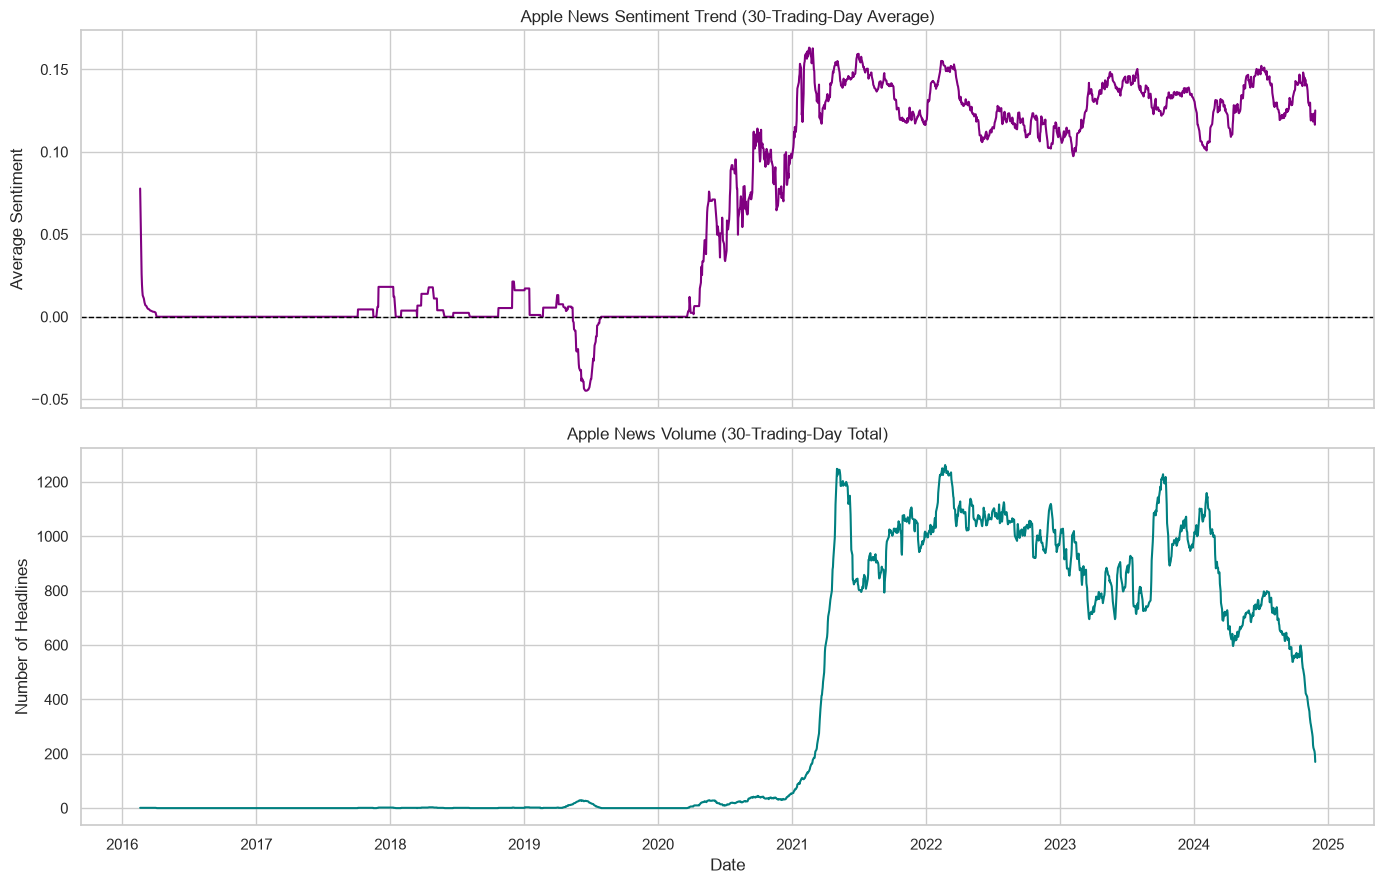

Sentiment trend graph saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\outputs\figures\aapl_sentiment_trends.png


In [10]:
# Create rolling sentiment and news-volume trends
sentiment_trend_data = modeling_data[
    [
        "Date",
        "Daily_Avg_Sentiment",
        "News_Count"
    ]
].copy()

sentiment_trend_data[
    "Rolling_Sentiment_30"
] = (
    sentiment_trend_data[
        "Daily_Avg_Sentiment"
    ]
    .rolling(window=30, min_periods=1)
    .mean()
)

sentiment_trend_data[
    "Rolling_News_Count_30"
] = (
    sentiment_trend_data[
        "News_Count"
    ]
    .rolling(window=30, min_periods=1)
    .sum()
)

# Plot the sentiment and news-volume trends
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

axes[0].plot(
    sentiment_trend_data["Date"],
    sentiment_trend_data["Rolling_Sentiment_30"],
    color="purple",
    linewidth=1.5
)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

axes[0].set_title(
    "Apple News Sentiment Trend (30-Trading-Day Average)"
)
axes[0].set_ylabel("Average Sentiment")

axes[1].plot(
    sentiment_trend_data["Date"],
    sentiment_trend_data["Rolling_News_Count_30"],
    color="teal",
    linewidth=1.5
)

axes[1].set_title(
    "Apple News Volume (30-Trading-Day Total)"
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of Headlines")

plt.tight_layout()

sentiment_trend_file = (
    figures_dir / "aapl_sentiment_trends.png"
)

plt.savefig(
    sentiment_trend_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Sentiment trend graph saved to:")
print(sentiment_trend_file)